### Before start, load inference environments, gpu, cuda, ...

In [1]:
from envs import actenv_jupyter, change_exp_dir, make_gpu_mem_reporter
actenv_jupyter(cuda_version="12.5", gcc_version="11", clear_cache=False)

[actenv_jupyter] CUDA_HOME=/usr/local/cuda-12.5
[actenv_jupyter] TORCH_CUDA_ARCH_LIST=8.0
[actenv_jupyter] CXX=/usr/bin/g++-11 | CC=/usr/bin/gcc-11
[actenv_jupyter] Ready.


{'CUDA_HOME': '/usr/local/cuda-12.5',
 'TORCH_CUDA_ARCH_LIST': '8.0',
 'CC': '/usr/bin/gcc-11',
 'CXX': '/usr/bin/g++-11',
 'CUDAHOSTCXX': '/usr/bin/g++-11',
 'CXXFLAGS': '-std=c++17',
 'PATH_head': '/usr/local/cuda-12.5/bin:/home/ids/yuhe/anaconda3/envs/styleGANenv/bin:/home/ids/yuhe/.vscode-server/cli/servers/Stable-b6a47e94e326b5c209d118cf0f994d6065585705/server/bin/remote-cli',
 'LD_LIBRARY_PATH_head': '/usr/local/cuda-12.5/lib64:',
 'TORCH_CUDA_VERBOSE_BUILD': '1',
 'MAX_JOBS': '1'}

### Set experiment dir and models' paths

In [2]:
import torch
import os
import yaml

root_dir = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN"
sfe_root = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS"
medminist_path = '/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets'

Paths = {
        "base_models": {
            "stylegan_weights":  "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/stylegan2/stylegan2_medical_images/brats_rosinality.pt",
            "stylegan_weights_pkl": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/styleGAN_ada/output/brats_resume/00000-brats256x256-mirror-paper256-ada-blit-resumecustom/network-snapshot-002419.pkl",
            "pSp_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/brats_ht_Ros_resume/checkpoints/iteration_20000.pt",
            "inverter_pth": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/inverter/brats_ht/fse_inverter_train_000/iteration_140000.pt",
            "sfe_path": sfe_root + "/experiments/fse_cs_editor_train/brats_ht/brats_ht_000/iteration_370000.pt",
        },

        "wo_regular": {
        "pSp_cs_path": root_dir +  "/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/wo_regular/checkpoints/iteration_100000.pt",
        "sfe_path": root_dir + "/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train/Regularization/wo_regular_000/iteration_430000.pt",
        },
        "with_D_only": {
        "pSp_cs_path": root_dir + "/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/adv_D_start_step1000/checkpoints/iteration_100000.pt",
        "sfe_path": root_dir + "/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train/Regularization/adv_D_only_000/iteration_350000.pt",
        },
        "with_DR_DiscMI": {
        "pSp_cs_path": root_dir + "/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/adv_DR_DiscMI/Exp4_startstep2000_Rlr0.05_Rlayer2_MLPlr0.001/checkpoints/iteration_110000.pt",
        "sfe_path": root_dir + "/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train/Regularization/adv_DR_DiscMI_000/iteration_430000.pt",
        },
        
        "with_DR_RegrMI_90k": {
        "pSp_cs_path": root_dir + "/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/adv_DR_RegrR/Exp4_startstep2000_Rlr0.05_Rlayer2_MLPlr0.001/checkpoints/iteration_90000.pt",
        "sfe_path": root_dir + "/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train/Regularization/RegrR_D_90k_000/iteration_430000.pt",
        },
        
        "with_DR_RegrMI_110k": {
        "pSp_cs_path": root_dir + "/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/adv_DR_RegrR/Exp4_startstep2000_Rlr0.05_Rlayer2_MLPlr0.001/checkpoints/iteration_110000.pt",
        "sfe_path": root_dir + "/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train/Regularization/RegrR_D_110k_000/iteration_430000.pt",
        }, 
        "with_DR_RegrMI_120k": {
        "pSp_cs_path": root_dir + "/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/adv_DR_RegrR/Exp4_startstep2000_Rlr0.05_Rlayer2_MLPlr0.001/checkpoints/iteration_120000.pt",
        "sfe_path": root_dir + "/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train/Regularization/RegrR_D_120k_000/iteration_430000.pt",
        },
        "with_DR_RegrMI_140k": {
        "pSp_cs_path": root_dir + "/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/adv_DR_RegrR/Exp4_startstep2000_Rlr0.05_Rlayer2_MLPlr0.001/checkpoints/iteration_140000.pt",
        "sfe_path": root_dir + "/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train/Regularization/RegrR_D_140k_000/iteration_430000.pt",
        },        
        }


change_exp_dir(sfe_root)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = 'with_DR_RegrMI_90k'


sfe_ckpt = Paths[model_name]["sfe_path"]

# Load config.yaml
config_yaml_path = os.path.join(os.path.dirname(sfe_ckpt), "config.yaml")
from omegaconf import OmegaConf
config = OmegaConf.load(config_yaml_path)
config.model.w_space_encoder = "pSp"

config.data.dataset="brats_ht_new"
config.model.checkpoint_path = sfe_ckpt
config.model.pSp_cs_path = Paths[model_name]["pSp_cs_path"]

config.model.batch_size = 4  # Set batch size for inference

# Pretty YAML (my favorite)
from omegaconf import OmegaConf
print(OmegaConf.to_yaml(config))



cwd: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS
Using device: cuda
exp:
  config_dir: configs
  config: fse_cs_editor_train.yaml
  exp_dir: ./experiments/
  name: fse_cs_editor_train/Regularization/RegrR_D_90k
  seed: 1
  root: .
  wandb: false
  wandb_project: sfe
  domain: human_faces
  exp_type: ffhq_glasses
data:
  data_dir: ???
  dataset: brats_ht_new
  transform: face_256
  special_idx: -1
train:
  train_runner: fse_editor_cs
  inverter_optimizer: ranger
  encoder_optimizer: ranger
  disc_optimizer: adam
  resume_path: ''
  val_metrics:
  - msssim
  - lpips
  - l2
  - fid
  start_step: 300000
  steps: 500000
  log_step: 2000
  checkpoint_step: 10000
  val_step: 2000
  train_dis: true
  train_disc_edit: false
  dis_train_start_step: 45000
  bs_used_before_adv_loss: 8
  disc_edits: []
  direction: two_directions
model:
  method: fse_full
  device: '0'
  batch_size: 4
  workers: 4
  checkpoint_path: /home/ids/yuhe/Projects/CA_wit

In [3]:
from envs import make_gpu_mem_reporter
print_memory = make_gpu_mem_reporter(gpu_index=0, clear_cache_on_setup=True)

print_memory("Before loading model")

from runners.simple_runner import SimpleRunner
runner = SimpleRunner(config=config)
sfe_model = runner.inference_runner
device = sfe_model.device

sfe_model.method.train()

print_memory("After loading model")


[Before loading model]
  - PyTorch Allocated : 0.00 GB
  - PyTorch Reserved  : 0.00 GB
  - Total GPU Used    : 0.51 GB / 40.00 GB



/home/ids/yuhe/anaconda3/envs/styleGANenv/lib/python3.11/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


Device: cuda:0
[DEBUG----------------------------] channel_multiplier = 1
[DEBUG----------------------------] stylegan_size = 256
n_styles:  14
Using pSp as w encoder, loading pSp-cs model ....
Loading pSp from checkpoint: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/brats_ht_Ros_resume/checkpoints/iteration_20000.pt
Loading cs mlp from path: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/Regularization/adv_DR_RegrR/Exp4_startstep2000_Rlr0.05_Rlayer2_MLPlr0.001/checkpoints/iteration_90000.pt
Loading discriminator from /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/styleGAN_ada/output/brats_resume/00000-brats256x256-mirror-paper256-ada-blit-resumecustom/network-snapshot-002419.pkl
✅ pkl loaded via legacy_load
✅ adapted b256.fromrgb.weight: (64, 1, 1, 1) -> (64, 3, 1, 1) (1ch->3ch)
✅ load_disc_any(module->ada): loaded all 64 keys (no mismatch).
✅ discriminator loaded from MODULE (re-instant

In [4]:
from torchvision.utils import save_image
from utils.common_utils import tensor2im, get_keys, visualize_batch_grid
from inference_ipynb.inference_funcs import get_latents_cs, calculate_delta_by_latent, recon_by_latent_w, recon_by_delta, configure_datasets, configure_Seg_datasets, preprocess_image, get_random_seeds
import shutil
from tqdm import tqdm
import torch
import torch.nn.functional as F
import random


def maybe_crop(img, crop_cfg):
    if crop_cfg is None:
        return img
    return crop_tensor(img, **crop_cfg)

def crop_tensor(
    img,        # Tensor: [C, H, W] or [H, W]
    w_l=0,
    w_r=0,
    h_top=0,
    h_bot=0,
):
    """
    Crop tensor image.

    Args:
        img: torch.Tensor
        w_l, w_r: pixels to crop from left / right
        h_top, h_bot: pixels to crop from top / bottom
    """
    if img.dim() == 3:
        _, H, W = img.shape
        return img[:, h_top:H - h_bot, w_l:W - w_r]
    elif img.dim() == 2:
        H, W = img.shape
        return img[h_top:H - h_bot, w_l:W - w_r]
    else:
        raise ValueError(f"Unsupported tensor shape: {img.shape}")

def inference(
    sfe_model,
    test_bg_dataloader,
    test_t_dataloader,
    idx,
    vis_mode="row",
    num_pairs=4,
    target_batch_idx=None, 
    crop_cfg=None,
    seed=0
):
    """
    vis_mode:
        - 'row': paper-style visualization (X on top, Y below)
        - 'col': column-wise visualization (X/Y side by side, multiple rows)

    target_batch_idx:
        - None: use first batch (default/debug)
        - int:  use the specified batch index (reproducible)
    """

    with torch.no_grad():
        for batch_idx, (batch_bg, batch_t) in tqdm(
            enumerate(zip(test_bg_dataloader, test_t_dataloader)),
            total=len(test_bg_dataloader)
        ):
            # ----------------------------------
            # skip until target batch
            # ----------------------------------
            if target_batch_idx is not None and batch_idx != target_batch_idx:
                continue

            X = batch_bg.to(device).float()
            Y = batch_t.to(device).float()

            X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
            Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)

            # ---- latent decomposition ----
            c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)

            # ---- recon in W space ----
            s_x_zero = torch.zeros_like(s_x)
            recon_w_X = recon_by_latent_w(c_x + s_x_zero, sfe_model)
            recon_w_Y = recon_by_latent_w(c_y + s_y, sfe_model)

            swap_w_X2Y = recon_by_latent_w(c_x + s_y, sfe_model)
            swap_w_Y2X = recon_by_latent_w(c_y + s_x_zero, sfe_model)

            # ---- recon in image (delta) space ----
            recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
            recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

            delta_x2y = calculate_delta_by_latent(c_x + s_x_zero, c_x + s_y, sfe_model)
            delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x_zero, sfe_model)

            swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model)
            swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model)

            # 👉 我们只需要一个 batch
            break

    # ==========================================================
    # Visualization
    # ==========================================================
    if vis_mode == "row":
        row1 = torch.stack(
            [
                maybe_crop(X[idx], crop_cfg),
                maybe_crop(recon_w_X[idx], crop_cfg),
                maybe_crop(swap_w_X2Y[idx], crop_cfg),
                maybe_crop(recon_f_X[idx], crop_cfg),
                maybe_crop(swap_f_X2Y[idx], crop_cfg),
            ],
            dim=0
        )

        row2 = torch.stack(
            [
                maybe_crop(Y[idx], crop_cfg),
                maybe_crop(recon_w_Y[idx], crop_cfg),
                maybe_crop(swap_w_Y2X[idx], crop_cfg),
                maybe_crop(recon_f_Y[idx], crop_cfg),
                maybe_crop(swap_f_Y2X[idx], crop_cfg),
            ],
            dim=0
        )


        columns = [torch.stack([row1[i], row2[i]], dim=0) for i in range(len(row1))]

        visualize_batch_grid(
            image_batches=columns,
            titles=[f"Input", "Recon W", "Swap W", "Recon F", "Swap F"],
            save_path=None,
            # wspace=wspace,   # 
            # hspace=hspace
        )

    elif vis_mode == "col":
        for i in range(num_pairs):
            col_X = torch.stack(
                [
                    maybe_crop(X[i], crop_cfg),
                    maybe_crop(recon_f_X[i], crop_cfg),
                    maybe_crop(swap_f_X2Y[i], crop_cfg),
                ],
                dim=0
            )

            col_Y = torch.stack(
                [
                    maybe_crop(Y[i], crop_cfg),
                    maybe_crop(recon_f_Y[i], crop_cfg),
                    maybe_crop(swap_f_Y2X[i], crop_cfg),
                ],
                dim=0
            )

            visualize_batch_grid(
                image_batches=[col_X, col_Y],
                titles=[f"X_{seed}_{i}", f"Y #{i}"],
                save_path=None,
                # wspace=wspace,   # 
                # hspace=hspace
            )

    else:
        raise ValueError(f"Unknown vis_mode: {vis_mode}")






def get_paired_random_batch(loader_X, loader_Y):
    """
    Returns one random paired batch (same batch index)
    from loader_X and loader_Y.
    """
    num_batches = len(loader_X)
    idx = random.randint(0, num_batches - 1)

    # iterate both loaders in sync
    for i, (batch_X, batch_Y) in enumerate(zip(loader_X, loader_Y)):
        if i == idx:
            return batch_X, batch_Y

    raise RuntimeError("Batch index out of range")

import numpy as np
def seed_experiments(seed):
    # Set the random seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # If you use multi-GPU.

    # Ensures deterministic behavior for some PyTorch operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



In [5]:
# import os, re
# import numpy as np
# import nibabel as nib
# from PIL import Image
# import matplotlib.pyplot as plt
# from matplotlib.colors import ListedColormap, BoundaryNorm

# LIST_PATH = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Segmentation/data/bratsHT_TUMOR_new/test_X.npy"
# SEG_ROOT_GLI = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/BraTS2023_GLI/TrainingData_nii/seg"
# T1N_ROOT = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/Preprocessed/BraTS2023_GLI/TrainingData_nii/t1n"

# def parse_png_path(png_path: str):
#     fname = os.path.basename(png_path)
#     m = re.match(r"(.+)_slice_(\d+)\.png$", fname)
#     if m is None:
#         raise ValueError(f"Bad filename: {fname}")
#     pid = m.group(1)
#     slice_id = int(m.group(2))
#     return pid, slice_id, fname

# def load_vol(path):
#     return np.asanyarray(nib.load(path).dataobj)

# def show_png_seg_t1n(png_path):
#     pid, slice_id, png_fname = parse_png_path(png_path)

#     s_path   = os.path.join(SEG_ROOT_GLI, f"{pid}-seg.nii.gz")
#     t1n_path = os.path.join(T1N_ROOT, f"{pid}-t1n.nii.gz")

#     s_name   = os.path.basename(s_path)
#     t1n_name = os.path.basename(t1n_path)

#     svol  = load_vol(s_path)
#     t1vol = load_vol(t1n_path)

#     s  = svol[:, :, slice_id]          # 0/1/2/3
#     t1 = t1vol[:, :, slice_id]
#     img = np.array(Image.open(png_path))

#     # seg 的 unique 值
#     u = np.unique(s)
#     print("PNG:", png_fname, "slice:", slice_id)
#     print("seg nii:", s_name, "unique:", u)

#     # --- 离散 colormap: 0/1/2/3 不同颜色 ---
#     # 你可以随便换颜色，这里用 4 个离散颜色
#     cmap = ListedColormap(["black", "red", "green", "blue"])
#     norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

#     plt.figure(figsize=(16,4))

#     # 1) PNG
#     ax1 = plt.subplot(1,3,1)
#     ax1.imshow(img, cmap="gray")
#     ax1.set_title(f"PNG: {png_fname}\nslice={slice_id}")
#     ax1.axis("off")

#     # 2) SEG 彩色
#     ax2 = plt.subplot(1,3,2)
#     im2 = ax2.imshow(s, cmap=cmap, norm=norm, interpolation="nearest")
#     ax2.set_title(f"SEG (colored): {s_name}\nslice={slice_id}")
#     ax2.axis("off")

#     # colorbar 标注类别
#     cbar = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, ticks=[0,1,2,3])
#     cbar.ax.set_yticklabels(["0","1","2","3"])

#     # 3) T1N
#     ax3 = plt.subplot(1,3,3)
#     ax3.imshow(t1, cmap="gray")
#     ax3.set_title(f"T1N: {t1n_name}\nslice={slice_id}")
#     ax3.axis("off")

#     plt.tight_layout()
#     plt.show()

# # 用法
# png_list = np.load(LIST_PATH, allow_pickle=True)
# png_list = [str(p) for p in png_list]
# show_png_seg_t1n(png_list[456])


In [6]:
# import numpy as np
# from PIL import Image
# import matplotlib.pyplot as plt

# # 需要 scipy 做形态学（一般都有；没有就 pip install scipy）
# from scipy import ndimage as ndi


# def otsu_threshold_uint8(img_uint8):
#     """Otsu 阈值 (0~255)，纯 numpy 实现"""
#     hist = np.bincount(img_uint8.ravel(), minlength=256).astype(np.float64)
#     total = img_uint8.size
#     prob = hist / (total + 1e-12)

#     omega = np.cumsum(prob)
#     mu = np.cumsum(prob * np.arange(256))
#     mu_t = mu[-1]

#     sigma_b2 = (mu_t * omega - mu) ** 2 / (omega * (1 - omega) + 1e-12)
#     k = int(np.argmax(sigma_b2))
#     return k


# def make_background_mask_from_png(png_path, open_iters=1, close_iters=2):
#     img = np.array(Image.open(png_path).convert("L"))  # (256,256) uint8

#     thr = otsu_threshold_uint8(img)
#     brain = img > thr  # 初始 brain mask

#     # 去掉小噪声 / 连接断裂
#     brain = ndi.binary_opening(brain, structure=np.ones((3,3)), iterations=open_iters)
#     brain = ndi.binary_closing(brain, structure=np.ones((5,5)), iterations=close_iters)

#     # 填洞
#     brain = ndi.binary_fill_holes(brain)

#     # 只保留最大连通区域（通常就是脑）
#     lab, n = ndi.label(brain)
#     if n > 0:
#         sizes = np.bincount(lab.ravel())
#         sizes[0] = 0
#         brain = lab == sizes.argmax()

#     brain01 = brain.astype(np.uint8)          # 0/1
#     bg01 = (1 - brain01).astype(np.uint8)     # 0/1

#     return img, brain01, bg01, thr


# # --- 用法：对 png_list[456] ---
# png_path = png_list[456]   # 你已经有 png_list 了
# img, brain01, bg01, thr = make_background_mask_from_png(png_path)

# print("png:", png_path)
# print("otsu thr:", thr)
# print("brain unique:", np.unique(brain01), "brain ratio:", brain01.mean())
# print("bg unique:", np.unique(bg01), "bg ratio:", bg01.mean())

# masked = img * brain01  # image * mask (mask 0/1)

# plt.figure(figsize=(16,4))
# plt.subplot(1,4,1); plt.imshow(img, cmap="gray"); plt.title("image"); plt.axis("off")
# plt.subplot(1,4,2); plt.imshow(brain01, cmap="gray"); plt.title("brain mask (0/1)"); plt.axis("off")
# plt.subplot(1,4,3); plt.imshow(bg01, cmap="gray"); plt.title("background mask (0/1)"); plt.axis("off")
# plt.subplot(1,4,4); plt.imshow(masked, cmap="gray"); plt.title("image * brain"); plt.axis("off")
# plt.tight_layout(); plt.show()


## Image qualitative evaluation

In [6]:
# SEED = get_random_seeds()


# SEED = 13002
# # seed_experiments(seed)
# # batch_X, batch_Y = get_paired_random_batch(
# #     test_bg_dataloader,
# #     test_t_dataloader
# # )
# bg_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Segmentation/data/bratsHT_TUMOR_new/test_X.npy"
# #t_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Segmentation/data/bratsHT_TUMOR_new/test_Y.npy"
# t_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/X_Y_splits/bratsHT_TUMOR_new/test_Y_examples_515.npy"

# # t_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/X_Y_splits/bratsHT_TUMOR_new/test_Y_examples_099.npy"
# # === Get data ===
# # sfe_model.config.data.dataset = 'bloodmnist'
# test_bg_dataloader, test_t_dataloader = configure_Seg_datasets(sfe_model.config, seed=SEED, shuffle=True, bg_path=bg_path, t_path=t_path)
# # loader_bg = DataLoader(
# #     dataset_bg,
# #     batch_size=config.data.batch_size,
# #     shuffle=False
# # )

# # loader_t = DataLoader(
# #     dataset_t,
# #     batch_size=config.data.batch_size,
# #     shuffle=False
# # )
# crop_margin = 20   # 每一边裁剪的像素数

# # =========================
# # 裁剪函数
# # =========================
# def crop_image(img, margin):
#     if margin <= 0:
#         return img
#     w, h = img.size
#     return img.crop((margin, margin, w - margin, h - margin))

# h = 10
# crop_cfg = dict(w_l=crop_margin+h, w_r=crop_margin - h, h_top=crop_margin, h_bot=crop_margin)

# %matplotlib inline
# inference(
#     sfe_model,
#     test_bg_dataloader,
#     test_t_dataloader,
#     idx=3,
#     vis_mode="col",
#     target_batch_idx=521,
#     crop_cfg=crop_cfg, #wspace=0.2, hspace=0.02,
#     seed = SEED
# )


In [5]:
# h = 2
# crop_cfg = dict(w_l=30-h, w_r=30 + h, h_top=30, h_bot=30)

# %matplotlib inline
# inference(
#     sfe_model,
#     test_bg_dataloader,
#     test_t_dataloader,
#     idx=3,
#     vis_mode="row",
#     target_batch_idx=114,
#     crop_cfg=crop_cfg
# )


# Image quantitative evaluation

In [5]:
# from time import time
# from datetime import datetime
# seed = get_random_seeds()

# from time import time
# from datetime import datetime

# def _sync_cuda(dev):
#     if torch.cuda.is_available() and str(dev).startswith("cuda"):
#         torch.cuda.synchronize()

# log_first_n_batches = 10  # 只打印前5个batch
# max_eval_batch = None
# # )
# # sfe_model.config.batch_size=1
# bg_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Segmentation/data/bratsHT_TUMOR_new/test_X.npy"
# # t_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/X_Y_splits/bratsHT_TUMOR_new/test_Y_examples_515.npy"
# # t_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/X_Y_splits/bratsHT_TUMOR_new/test_Y_examples_099.npy"
# # t_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/X_Y_splits/bratsHT_TUMOR_new/test_Y_examples_09998.npy"
# t_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging/brats/X_Y_splits/bratsHT_TUMOR_new/test_Y_examples_099985.npy"
# test_bg_dataloader, test_t_dataloader = configure_Seg_datasets(sfe_model.config, seed=seed, shuffle=False, bg_path=bg_path, t_path=t_path)


# def _sync_cuda(dev):
#     if torch.cuda.is_available() and str(dev).startswith("cuda"):
#         torch.cuda.synchronize()



# fixed_bs = sfe_model.config.model.batch_size
# t_iter = iter(test_t_dataloader)

# with torch.no_grad():
#     for batch_idx, batch_bg in tqdm(enumerate(test_bg_dataloader), total=len(test_bg_dataloader)):
#         if max_eval_batch is not None and batch_idx >= max_eval_batch:
#             break

#         _sync_cuda(device)
#         t_batch0 = time()

#         # target loader 循环
#         try:
#             batch_t = next(t_iter)
#         except StopIteration:
#             t_iter = iter(test_t_dataloader)
#             batch_t = next(t_iter)

#         X = batch_bg.to(device).float()
#         Y = batch_t.to(device).float()

#         B = min(X.size(0), Y.size(0))
#         if B == 0:
#             continue
#         X = X[:B]
#         Y = Y[:B]

#         # resize
#         _sync_cuda(device); t0 = time()
#         X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
#         Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)
#         _sync_cuda(device); t_resize = time() - t0

#         # cs
#         _sync_cuda(device); t0 = time()
#         c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)
#         _sync_cuda(device); t_cs = time() - t0

#         # w recon/swap
#         _sync_cuda(device); t0 = time()
#         s_x = torch.zeros_like(s_x)
#         recon_w_X = recon_by_latent_w(c_x + s_x, sfe_model)
#         recon_w_Y = recon_by_latent_w(c_y + s_y, sfe_model)
#         swap_w_X2Y = recon_by_latent_w(c_x + s_y, sfe_model)
#         swap_w_Y2X = recon_by_latent_w(c_y + s_x, sfe_model)
#         _sync_cuda(device); t_w = time() - t0

#         # f recon + delta + swap_f
#         _sync_cuda(device); t0 = time()
#         recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
#         recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

#         delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
#         delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)

#         swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model=sfe_model)
#         swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model=sfe_model)
#         _sync_cuda(device); t_f = time() - t0

#         images = {
#             "real_X": X,
#             "real_Y": Y,
#             "recon_w_X": recon_w_X,
#             "recon_w_Y": recon_w_Y,
#             "swap_w_X2Y": swap_w_X2Y,
#             "swap_w_Y2X": swap_w_Y2X,
#             "recon_f_X": recon_f_X,
#             "recon_f_Y": recon_f_Y,
#             "swap_f_X2Y": swap_f_X2Y,
#             "swap_f_Y2X": swap_f_Y2X,
#         }

#         # postprocess
#         _sync_cuda(device); t0 = time()
#         images = {k: (None if v is None else preprocess_image(v)) for k, v in images.items()}
#         _sync_cuda(device); t_post = time() - t0

#         _sync_cuda(device)
#         t_total = time() - t_batch0
#         t_infer = t_resize + t_cs + t_w + t_f + t_post
#         avg = t_total / max(B, 1)

#         if batch_idx < log_first_n_batches:
#             ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
#             print(
#                 f"{ts} | BATCH {batch_idx} | B={B} | "
#                 f"total={t_total:.2f}s | avg={avg:.2f}s/img | infer_sum={t_infer:.2f}s | "
#                 f"resize={t_resize:.2f}s cs={t_cs:.2f}s w={t_w:.2f}s f={t_f:.2f}s post={t_post:.2f}s"
#             )


In [5]:
seed = get_random_seeds()

# from time import time
# from datetime import datetime

# )

bg_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Segmentation/data/bratsHT_TUMOR_new/test_X.npy"

t_name = "BraTS-GLI-00604-000_slice_100" # BraTS-GLI-00604-000_slice_100    BraTS-GLI-01072-000_slice_080   BraTS-GLI-01101-000_slice_107.npy  BraTS-GLI-01120-000_slice_072.npy  BraTS-GLI-01368-000_slice_109.npy


t_path = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/diffusion_quantative_results/Segment_statics/segmentY_list/{t_name}.npy"


test_bg_dataloader, test_t_dataloader = configure_Seg_datasets(sfe_model.config, seed=seed, shuffle=False, bg_path=bg_path, t_path=t_path)

# exp_name = f"{model_name}/images/{ds_name}"
save_image_dir = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/diffusion_quantative_results/Segment_statics/segmentY_list/{t_name}"

max_eval_batch = None

if os.path.exists(save_image_dir):
    shutil.rmtree(save_image_dir)

# image_paths = ['real_X', 'real_Y', 'recon_w_X', 'recon_w_Y', 'swap_w_Y2X', 'swap_w_X2Y', 'recon_f_X', 'recon_f_Y', 'swap_f_X2Y', 'swap_f_Y2X']
image_paths = ['swap_w_Y2X', 'swap_w_X2Y', 'swap_f_X2Y', 'swap_f_Y2X']
for path in image_paths:
    dir_path = os.path.join(save_image_dir, path)
    os.makedirs(dir_path)


import os
import shutil
from tqdm import tqdm
import torch
import torch.nn.functional as F
from torchvision.utils import save_image

def infinite_loader(dataloader):
    """不缓存数据的无限循环 dataloader"""
    while True:
        for batch in dataloader:
            yield batch

# ------------------------
# build infinite target iterator
# ------------------------
t_iter = infinite_loader(test_t_dataloader)

global_idx = 0  # 用全局计数，避免 batch_size 变化导致 idx 重复/跳号

with torch.no_grad():
    for batch_idx, batch_bg in tqdm(enumerate(test_bg_dataloader), total=len(test_bg_dataloader)):
        if max_eval_batch is not None and batch_idx >= max_eval_batch:
            break

        batch_t = next(t_iter)  # ⭐ 永远能取到（t 会循环）

        X = batch_bg.to(device).float()
        Y = batch_t.to(device).float()

        # ------------------------
        # 关键：以 X 的 batch 为准，让 Y 对齐到同样的 batch size
        # ------------------------
        Bx = X.size(0)
        By = Y.size(0)
        if By < Bx:
            reps = (Bx + By - 1) // By
            Y = Y.repeat(reps, 1, 1, 1)[:Bx]
        else:
            Y = Y[:Bx]

        # resize
        X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
        Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)

        # cs
        c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)

        # w recon/swap
        s_x = torch.zeros_like(s_x)
        swap_w_X2Y = recon_by_latent_w(c_x + s_y, sfe_model)
        swap_w_Y2X = recon_by_latent_w(c_y + s_x, sfe_model)

        # f recon + delta + swap_f
        delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
        delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)

        swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model=sfe_model)
        swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model=sfe_model)

        images = {
            "swap_w_X2Y": swap_w_X2Y,
            "swap_w_Y2X": swap_w_Y2X,
            "swap_f_X2Y": swap_f_X2Y,
            "swap_f_Y2X": swap_f_Y2X,
        }

        images = {k: (None if v is None else preprocess_image(v)) for k, v in images.items()}

        # save (用 global_idx 确保每个 X 对应唯一编号)
        B = X.size(0)
        for i in range(B):
            idx = global_idx
            global_idx += 1
            for key, tensor in images.items():
                if tensor is None or tensor.ndim != 4 or i >= tensor.size(0):
                    continue
                img_i = tensor[i].detach().cpu().clamp(0, 1)
                save_image(img_i, os.path.join(save_image_dir, key, f"{idx}.png"))

print(f"Results images saved to {save_image_dir}")


Random seed: 3611
Loading dataset
Using dataset: brats_ht_new


100%|██████████| 521/521 [12:52<00:00,  1.48s/it]

Results images saved to /home/ids/yuhe/Projects/CA_with_GAN/3_code/diffusion_quantative_results/Segment_statics/segmentY_list/BraTS-GLI-00604-000_slice_100


## Latent separation evaluation

In [ ]:
# seed = get_random_seeds()

# # ds_name = 'brats_ht'
# # ds_name = 'brats_ht_new'
# # ds_name = 'BraTS_evaluation'
# # ds_name = 'BraTS_evaluation_70_100'

# # ds_name = 'brats_ht_new'
# bg_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Segmentation/data/bratsHT_TUMOR_new/test_X.npy"
# t_path = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Segmentation/data/bratsHT_TUMOR_new/test_Y.npy"

# test_bg_dataloader, test_t_dataloader = configure_Seg_datasets(sfe_model.config, seed=SEED, shuffle=False, bg_path=bg_path, t_path=t_path)

# # test_bg_dataloader, test_t_dataloader = configure_Seg_datasets(sfe_model.config, seed=seed, shuffle=False, bg_path=bg_path, t_path=t_path)
# # test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=False, ds_name=ds_name)

# # exp_name = f"{model_name}/images/{ds_name}"
# save_image_dir = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/Regularization/unsorted_path/{model_name}/latents"
# # save_image_dir = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Segmentation/data/train_on_Y_test_on_X/argumentations"
# max_eval_batch = None
# max_eval_batch = None

# if os.path.exists(save_image_dir):
#     shutil.rmtree(save_image_dir)

# # Prepare directories for saving images
# latent_paths = ['latents_x', 'latents_y']

# for path in latent_paths:
#     dir_path = os.path.join(save_image_dir, path)
#     if os.path.exists(dir_path):
#             shutil.rmtree(dir_path)
#     os.makedirs(dir_path)


# sfe_model.method.train()
# with torch.no_grad():
#     for batch_idx, (batch_bg, batch_t) in tqdm(enumerate(zip(test_bg_dataloader, test_t_dataloader)), total=len(test_bg_dataloader)):
#         if max_eval_batch is not None and batch_idx >= max_eval_batch:
#             break

#         X = batch_bg.to(device).float()
#         Y = batch_t.to(device).float()
        
#         X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
#         Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)        

#         c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)

#         # Group latents for background (x) and target (y)
#         latents = {
#             "x": {"c": c_x, "s": s_x},
#             "y": {"c": c_y, "s": s_y},
#         }

#         # Save latents per sample
#         batch_size = X.size(0)
#         for i in range(batch_size):
#             idx = batch_idx * batch_size + i
#             for key in ["x", "y"]:
#                 save_path = os.path.join(save_image_dir, f"latents_{key}", f"latent_{key}_{idx}.pt")
#                 torch.save({k: v[i].cpu() for k, v in latents[key].items()}, save_path)


Random seed: 15769
Loading dataset
Using dataset: brats_ht_new


100%|██████████| 521/521 [00:56<00:00,  9.20it/s]


In [5]:
import os
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


# ============================================================
# A1) Path setup + import load_classifier
# ============================================================
def setup_repo_and_import_loader(repo_root: str):
    repo_root = str(Path(repo_root).resolve())

    if repo_root in sys.path:
        sys.path.remove(repo_root)
    sys.path.insert(0, repo_root)

    # 清缓存，避免之前 import 指到错误模块
    for k in list(sys.modules.keys()):
        if k == "models" or k.startswith("models.") or k == "CFgenerating" or k.startswith("CFgenerating."):
            sys.modules.pop(k, None)

    from CFgenerating.model_loading import load_classifier
    return load_classifier


def load_cls(ckpt_path: str, model_type: str, device: str):
    load_classifier = setup_repo_and_import_loader("/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med")
    cls = load_classifier(ckpt_path, model_type, device)
    cls.eval()
    return cls


# ============================================================
# A2) Preprocess: 3ch -> 1ch + (optional) PNG quantization
# ============================================================
def rgb_to_gray_luma(x: torch.Tensor) -> torch.Tensor:
    """
    x: [N,3,H,W] in [-1,1] (or any range, linear OK)
    return: [N,1,H,W]
    """
    r, g, b = x[:, 0:1], x[:, 1:2], x[:, 2:3]
    return 0.2989 * r + 0.5870 * g + 0.1140 * b


def ensure_1ch(x: torch.Tensor) -> torch.Tensor:
    """
    x: [N,C,H,W] -> [N,1,H,W]
    """
    if x.shape[1] == 1:
        return x
    if x.shape[1] == 3:
        return rgb_to_gray_luma(x)
    return x.mean(dim=1, keepdim=True)


def quantize_like_png(x: torch.Tensor) -> torch.Tensor:
    """
    模拟 classify_folder.py 的 PNG 8-bit 量化再读回：
    x: [N,1,H,W] in [-1,1]
    return: [N,1,H,W] in [-1,1]
    """
    x = x.clamp(-1, 1)
    u8 = (((x + 1) / 2) * 255.0).round().clamp(0, 255).to(torch.uint8)
    xq = (u8.float() / 255.0) * 2.0 - 1.0
    return xq


def preprocess_for_classifier(imgs: torch.Tensor, do_png_quant: bool = True) -> torch.Tensor:
    """
    imgs: [N,C,H,W] in [-1,1]  (C can be 1 or 3)
    """
    imgs = ensure_1ch(imgs)
    if do_png_quant:
        imgs = quantize_like_png(imgs)
    return imgs


# ============================================================
# A3) Batch prob for recon list
# ============================================================
@torch.no_grad()
def probs_for_recon_list(recon_list, classifier, device, t_val=0, idx_in_batch=0, do_png_quant=True):
    """
    recon_list: list of tensors, each [B,3,256,256] (or [B,1,256,256]) in [-1,1]
    """
    imgs = torch.cat([x[idx_in_batch:idx_in_batch+1] for x in recon_list], dim=0).float().to(device)  # [N,C,H,W]
    imgs = preprocess_for_classifier(imgs, do_png_quant=do_png_quant)                                  # [N,1,H,W]

    t = torch.full((imgs.shape[0],), int(t_val), device=device, dtype=torch.long)
    logits = classifier(imgs, t).view(-1)
    probs = torch.sigmoid(logits)
    return probs.detach().cpu().numpy(), logits.detach().cpu().numpy()


# ============================================================
# A4) Visualization helpers: crop + overlay + plotting
# ============================================================
def crop_image(img, w_l=0, w_r=0, h_top=0, h_bot=0):
    w, h = img.size
    return img.crop((w_l, h_top, w - w_r, h - h_bot))


def tensor_to_cropped_img(t, crop_cfg):
    """
    t: tensor [C,H,W] in [-1,1]
    return: numpy image for imshow
    """
    t = ((t.clamp(-1, 1) + 1) / 2).detach().cpu()
    if t.shape[0] == 1:
        img = (t.squeeze(0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img, mode="L")
    else:
        img = (t.permute(1, 2, 0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img)
    pil_img = crop_image(pil_img, **crop_cfg)
    return np.array(pil_img)


def add_prob_overlay(ax, prob, fontsize=14):
    ax.text(
        0.02, 0.98, f"P(tumor)={prob:.3f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        color="white",
        bbox=dict(facecolor="black", alpha=0.6, pad=2, edgecolor="none"),
        zorder=10,
        clip_on=True,
    )


def plot_row_with_overlay(recon_list, probs, titles, crop_cfg, figsize_scale=2.2, title_fs=18, prob_fs=14):
    num_images = len(recon_list)
    col_spacing = 0.0
    total_width = 1.0
    img_width = (total_width - (num_images - 1) * col_spacing) / num_images
    title_height = 0.10

    fig = plt.figure(figsize=(num_images * figsize_scale, 3.0))
    for i in range(num_images):
        left = i * (img_width + col_spacing)
        ax = fig.add_axes([left, 0, img_width, 1 - title_height])

        img = tensor_to_cropped_img(recon_list[i][0], crop_cfg)  # 显示 batch 第0张
        ax.imshow(img)
        ax.axis("off")

        ax.set_title(titles[i], fontsize=title_fs, pad=2)
        add_prob_overlay(ax, probs[i], fontsize=prob_fs)

    plt.show()


def plot_alpha_prob_curves(alphas, probs, title, mode="discrete"):
    """
    mode:
      - "discrete": x=0..N-1, tick labels: real, 0.0..1.0
      - "continuous": x=-0.05,0..1 (real at -0.05)
    """
    if mode == "continuous":
        x_axis = np.concatenate(([-0.05], alphas.detach().cpu().numpy()))
        plt.figure(figsize=(6,4))
        plt.plot(x_axis, probs, marker="o")
        plt.xlabel("alpha (real at -0.05)")
    else:
        xs = np.arange(len(probs))  # 0..N-1
        labels = ["real"] + [f"{a:.1f}" for a in alphas.detach().cpu().numpy()]
        plt.figure(figsize=(7,4))
        plt.plot(xs, probs, marker="o")
        plt.xticks(xs, labels)
        plt.xlabel("alpha")

    plt.ylim(0, 1)
    plt.ylabel("P(tumor)")
    plt.title(title)
    plt.grid(True)
    plt.show()


## Interpolation

In [6]:
# import sys
# import importlib
# from pathlib import Path

# PROJECT_ROOT = Path("/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med").resolve()

# # 1) 把项目根目录放到 sys.path 最前面（确保优先用你的项目）
# if str(PROJECT_ROOT) not in sys.path:
#     sys.path.insert(0, str(PROJECT_ROOT))
# else:
#     # 如果已经在里面，挪到最前面
#     sys.path.remove(str(PROJECT_ROOT))
#     sys.path.insert(0, str(PROJECT_ROOT))

# # 2) 清掉已经缓存的 models（非常关键：避免之前 import 到别的同名 models）
# for k in list(sys.modules.keys()):
#     if k == "models" or k.startswith("models."):
#         sys.modules.pop(k, None)

# # 3) 现在重新 import models，并确认它来自哪里
# import models
# print("models module =", models)
# print("models __file__ =", getattr(models, "__file__", None))
# print("models __path__ =", list(getattr(models, "__path__", [])))

# # 4) 检查你项目里的 models 目录到底有哪些文件
# models_dir = PROJECT_ROOT / "models"
# print("\nYour project models_dir =", models_dir)
# print("models_dir exists =", models_dir.exists())
# if models_dir.exists():
#     print("models_dir files =", sorted([p.name for p in models_dir.iterdir()]))

# # 5) 尝试 import models.cnn
# import models.cnn
# print("\n✅ import models.cnn SUCCESS:", models.cnn)


In [12]:
recon_X_alpha[0].shape

torch.Size([4, 3, 256, 256])

Random seed: 4138
Loading dataset
Using dataset: brats_ht_new


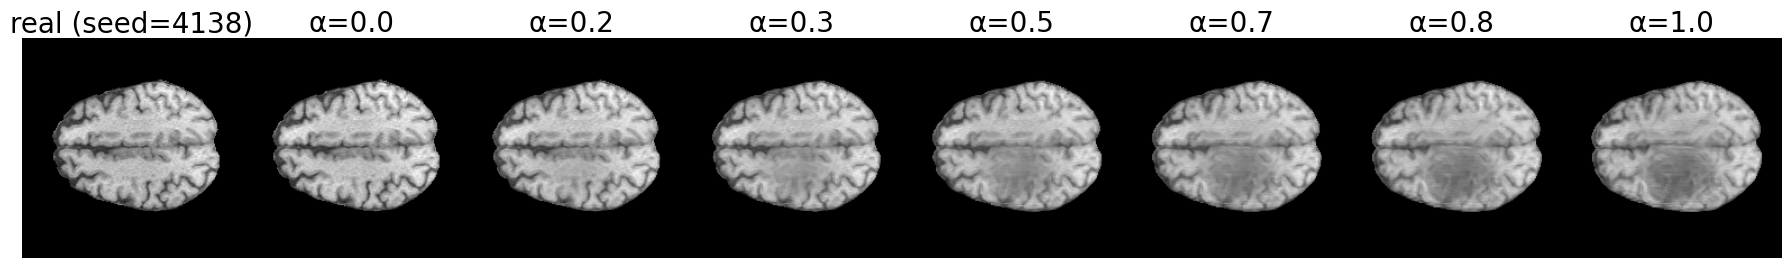

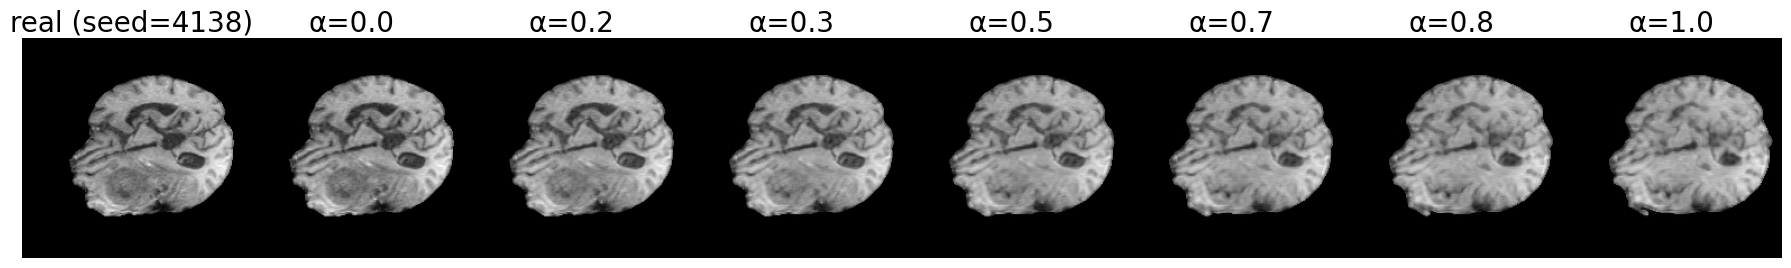

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# =========================
# Seed & Data
# =========================
seed = get_random_seeds()
# seed = 13477
test_bg_dataloader, test_t_dataloader = configure_datasets(
    sfe_model.config,
    test_images=True,
    seed=seed,
    shuffle=True
)

batch_bg = next(iter(test_bg_dataloader))
batch_t  = next(iter(test_t_dataloader))

# =========================
# Alpha Range
# =========================
alphas_x = torch.linspace(0, 1, steps=7)
alphas_y = torch.linspace(0, 1, steps=7)

titles_x = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_x]
titles_y = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_y]

# =========================
# Prepare Reconstructions
# =========================
recon_X_alpha = []
recon_Y_alpha = []

with torch.no_grad():
    sfe_model.method.train()

    X = batch_bg.to(device).float()
    Y = batch_t.to(device).float()

    X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
    Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)

    c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)

    # real images
    recon_X_alpha.append(X_resh)
    recon_Y_alpha.append(Y_resh)

    delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
    delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)

    for alpha_x, alpha_y in zip(alphas_x, alphas_y):
        swap_f_X2Y = recon_by_delta(X_resh, alpha_x * delta_x2y, sfe_model=sfe_model)
        swap_f_Y2X = recon_by_delta(Y_resh, alpha_y * delta_y2x, sfe_model=sfe_model)

        recon_X_alpha.append(swap_f_X2Y)
        recon_Y_alpha.append(swap_f_Y2X)

# =========================
# Crop Utils (你要用的那套)
# =========================
def crop_image(img, w_l=0, w_r=0, h_top=0, h_bot=0):
    w, h = img.size
    return img.crop((w_l, h_top, w - w_r, h - h_bot))

def tensor_to_cropped_img(t, crop_cfg):
    """
    t: tensor [C,H,W] in [-1,1]
    return: numpy image for imshow
    """
    t = ((t.clamp(-1, 1) + 1) / 2).detach().cpu()

    if t.shape[0] == 1:
        img = (t.squeeze(0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img, mode="L")
    else:
        img = (t.permute(1, 2, 0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img)

    pil_img = crop_image(pil_img, **crop_cfg)
    return np.array(pil_img)

# =========================
# Crop Config
# =========================
h = 5
crop_cfg = dict(
    w_l=30 + h,
    w_r=30 - h,
    h_top=30,
    h_bot=30
)

# =========================
# Visualization
# =========================
num_images = len(recon_X_alpha)
col_spacing = 0.0
title_height = 0.05
total_width = 1.0
img_width = (total_width - (num_images - 1) * col_spacing) / num_images

%matplotlib inline

# --- FIGURE 1: X row ---
fig_x = plt.figure(figsize=(num_images * 2.2, 2.5))
for i in range(num_images):
    left = i * (img_width + col_spacing)
    ax = fig_x.add_axes([left, 0, img_width, 1 - title_height])

    img = tensor_to_cropped_img(recon_X_alpha[i][0], crop_cfg)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(titles_x[i], fontsize=20, pad=2)

plt.show()

# --- FIGURE 2: Y row ---
fig_y = plt.figure(figsize=(num_images * 2.2, 2.5))
for i in range(num_images):
    left = i * (img_width + col_spacing)
    ax = fig_y.add_axes([left, 0, img_width, 1])

    img = tensor_to_cropped_img(recon_Y_alpha[i][0], crop_cfg)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(titles_y[i], fontsize=20, pad=2)

plt.show()


# 13477 4138

✅ load_classifier import OK
config_set={'model_name': 'unet_encoder', 'model_scale': '50', 'loss_func': 'WeightedBCE', 'weights': [1.0], 'weight_decay': 0.05, 'img_manipulation': 'add_noise', 'sd': <models.diffusion.GuidedDiffusion object at 0x716f79bd08d0>, 'timestep_range': 400, 'diff_train_from_ds': 'brats_2D_256', 'diff_version_num': 0, 'ds_name': 'brats_2D_256', 'img_size': (1, 256, 256), 'labels': ['non-tumor', 'tumor'], 'epochs': 50, 'batch_size': 16, 'lr': 1e-06, 'dropout_rate': 0.5, 'accelerator': 'gpu', 'strategy': 'auto', 'devices': 1, 'num_nodes': 1, 'num_workers': 16, 'device_name': 'cuda'}
[load_classifier] image_size=256, in_channels=1
[load_classifier] channel_mult=(1, 1, 2, 2, 4, 4), attention_ds=(8, 16, 32)
[load_classifier] inferred out_channels/num_classes=1
✅ classifier loaded on: cuda
Random seed: 12805
Loading dataset
Using dataset: brats_ht_new
recon_X_alpha[0] shape: torch.Size([4, 3, 256, 256])
recon_Y_alpha[0] shape: torch.Size([4, 3, 256, 256])
X row probs: 

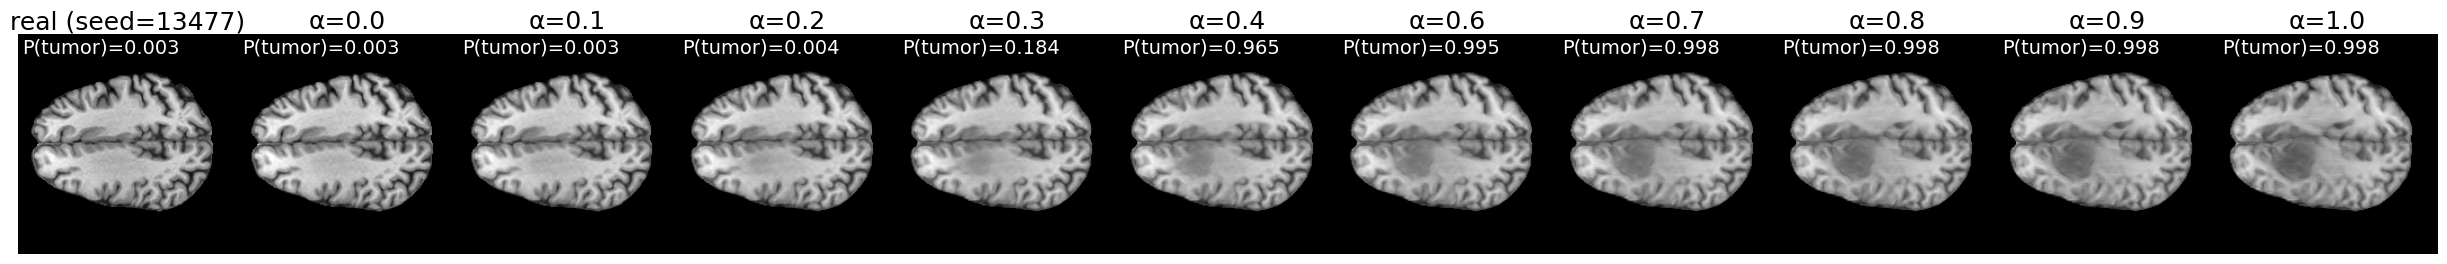

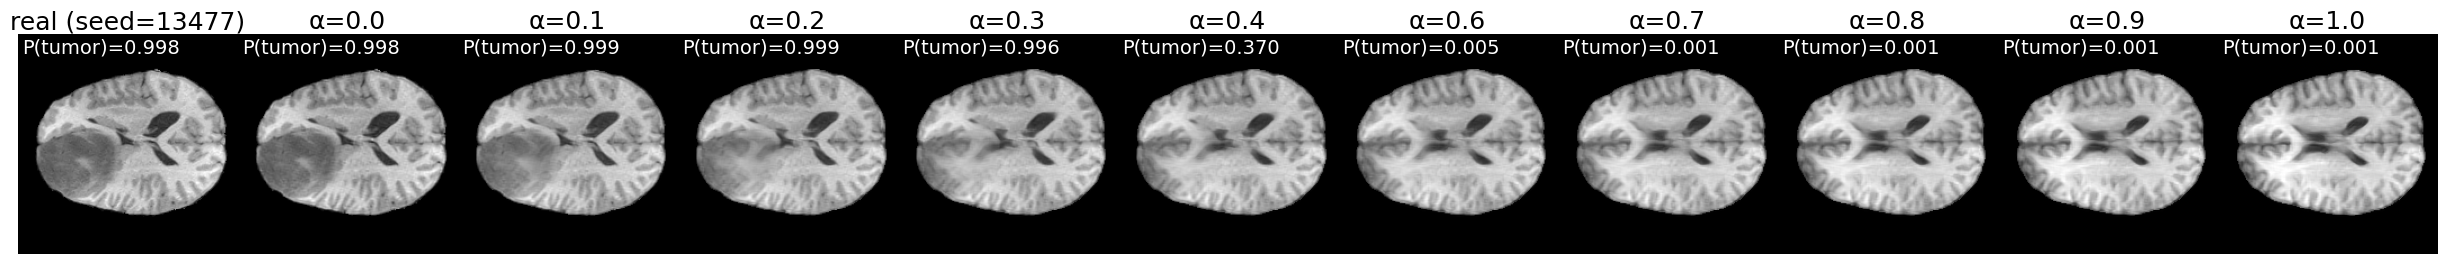

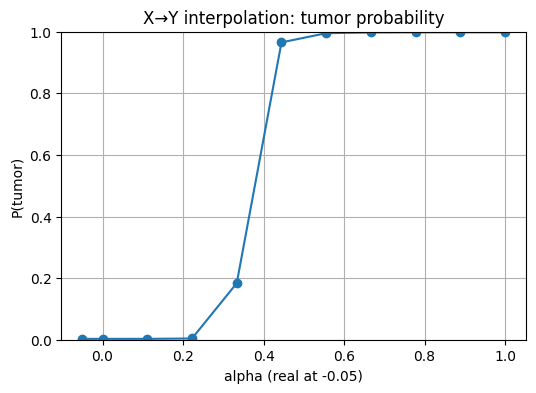

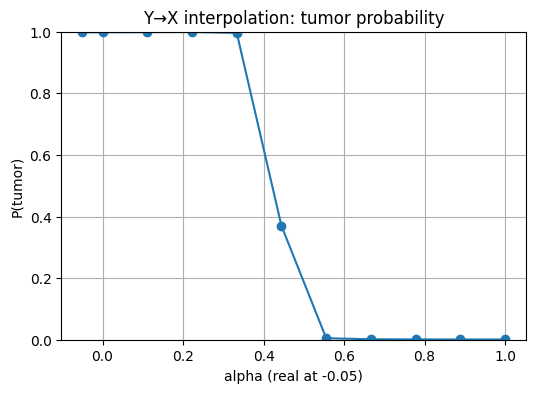

In [28]:
import os
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


# ============================================================
# 0) Add repo to sys.path + import classifier loader
# ============================================================
PROJECT_ROOT = Path("/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med").resolve()

# 确保项目根目录在 sys.path 最前
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

# 清掉缓存（避免之前 import 到错误模块）
for k in list(sys.modules.keys()):
    if k == "models" or k.startswith("models.") or k == "CFgenerating" or k.startswith("CFgenerating."):
        sys.modules.pop(k, None)

from CFgenerating.model_loading import load_classifier
print("✅ load_classifier import OK")


# ============================================================
# 1) Load classifier
# ============================================================
CKPT_PATH = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/unet_encoder-42/lightning_logs/version_4/checkpoints/loss-epoch=45-val_loss=0.032.ckpt"

device = "cuda" if torch.cuda.is_available() else "cpu"
classifier = load_classifier(CKPT_PATH, "unet_encoder", device)
classifier.eval()
print("✅ classifier loaded on:", device)


# ============================================================
# 2) Seed & Data
# ============================================================
seed = get_random_seeds()  # 或者你手动 seed=13477
seed = 13477

test_bg_dataloader, test_t_dataloader = configure_datasets(
    sfe_model.config,
    test_images=True,
    seed=seed,
    shuffle=True
)

batch_bg = next(iter(test_bg_dataloader))
batch_t  = next(iter(test_t_dataloader))


# ============================================================
# 3) Alpha Range
# ============================================================
alphas_x = torch.linspace(0, 1, steps=10)
alphas_y = torch.linspace(0, 1, steps=10)

titles_x = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_x]
titles_y = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_y]


# ============================================================
# 4) Prepare Reconstructions (interpolation)
# ============================================================
recon_X_alpha = []
recon_Y_alpha = []

with torch.no_grad():
    # 如果你需要 method 在 train mode 才能跑你的 pipeline，就保留
    sfe_model.method.train()

    X = batch_bg.to(device).float()
    Y = batch_t.to(device).float()

    X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
    Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)

    c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)

    # real
    recon_X_alpha.append(X_resh)
    recon_Y_alpha.append(Y_resh)

    # deltas
    delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
    delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)

    # interpolation
    for alpha_x, alpha_y in zip(alphas_x, alphas_y):
        swap_f_X2Y = recon_by_delta(X_resh, alpha_x * delta_x2y, sfe_model=sfe_model)
        swap_f_Y2X = recon_by_delta(Y_resh, alpha_y * delta_y2x, sfe_model=sfe_model)
        recon_X_alpha.append(swap_f_X2Y)
        recon_Y_alpha.append(swap_f_Y2X)

print("recon_X_alpha[0] shape:", recon_X_alpha[0].shape)  # 期望 [B,3,256,256]
print("recon_Y_alpha[0] shape:", recon_Y_alpha[0].shape)


# ============================================================
# 5) Classifier prob for each interpolation (3ch -> 1ch)
# ============================================================
def rgb_to_gray_luma(x: torch.Tensor) -> torch.Tensor:
    """
    x: [N,3,H,W] in [-1,1]
    return: [N,1,H,W] (luma weights, similar to PIL convert('L'))
    """
    r, g, b = x[:, 0:1], x[:, 1:2], x[:, 2:3]
    return 0.2989 * r + 0.5870 * g + 0.1140 * b

def ensure_1ch(x: torch.Tensor) -> torch.Tensor:
    """
    x: [N,C,H,W] -> [N,1,H,W]
    """
    if x.shape[1] == 1:
        return x
    if x.shape[1] == 3:
        return rgb_to_gray_luma(x)
    return x.mean(dim=1, keepdim=True)

def probs_for_recon_list(recon_list, classifier, device, t_val=0, idx_in_batch=0):
    """
    recon_list: list of tensors, each [B,3,256,256] in [-1,1]
    idx_in_batch: 取 batch 中第几张做展示/分类（你展示用 0 就一致）
    """
    # 拼成 [N,C,H,W]
    imgs = torch.cat([x[idx_in_batch:idx_in_batch+1] for x in recon_list], dim=0).float().to(device)
    imgs = ensure_1ch(imgs)  # ⭐ 3ch -> 1ch

    t = torch.full((imgs.shape[0],), int(t_val), device=device, dtype=torch.long)

    classifier.eval()
    with torch.no_grad():
        logits = classifier(imgs, t).view(-1)
        probs  = torch.sigmoid(logits)

    return probs.detach().cpu().numpy(), logits.detach().cpu().numpy()

probs_x, logits_x = probs_for_recon_list(recon_X_alpha, classifier, device, t_val=0, idx_in_batch=0)
probs_y, logits_y = probs_for_recon_list(recon_Y_alpha, classifier, device, t_val=0, idx_in_batch=0)

print("X row probs:", probs_x)
print("Y row probs:", probs_y)


# ============================================================
# 6) Crop utils (你原来的显示方式)
# ============================================================
def crop_image(img, w_l=0, w_r=0, h_top=0, h_bot=0):
    w, h = img.size
    return img.crop((w_l, h_top, w - w_r, h - h_bot))

def tensor_to_cropped_img(t, crop_cfg):
    """
    t: tensor [C,H,W] in [-1,1]
    return: numpy image for imshow
    """
    t = ((t.clamp(-1, 1) + 1) / 2).detach().cpu()

    if t.shape[0] == 1:
        img = (t.squeeze(0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img, mode="L")
    else:
        img = (t.permute(1, 2, 0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img)

    pil_img = crop_image(pil_img, **crop_cfg)
    return np.array(pil_img)

h = 5
crop_cfg = dict(
    w_l=30 + h,
    w_r=30 - h,
    h_top=30,
    h_bot=30
)


# ============================================================
# 7) Visualization: title shows alpha, overlay shows prob
# ============================================================
def add_prob_overlay(ax, prob, fontsize=14):
    ax.text(
         0.02, 0.98, f"P(tumor)={prob:.3f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        color="white",
        bbox=dict(facecolor="black", alpha=0.6, pad=2, edgecolor="none"),
    )

num_images   = len(recon_X_alpha)
col_spacing  = 0.0
total_width  = 1.0
img_width    = (total_width - (num_images - 1) * col_spacing) / num_images
title_height = 0.10

# --- FIGURE 1: X row ---
fig_x = plt.figure(figsize=(num_images * 2.2, 3.0))
for i in range(num_images):
    left = i * (img_width + col_spacing)
    ax = fig_x.add_axes([left, 0, img_width, 1 - title_height])

    img = tensor_to_cropped_img(recon_X_alpha[i][0], crop_cfg)
    ax.imshow(img)
    ax.axis("off")

    ax.set_title(titles_x[i], fontsize=18, pad=2)  # 只显示 alpha
    add_prob_overlay(ax, probs_x[i], fontsize=14)  # 左上角 prob

plt.show()

# --- FIGURE 2: Y row ---
fig_y = plt.figure(figsize=(num_images * 2.2, 3.0))
for i in range(num_images):
    left = i * (img_width + col_spacing)
    ax = fig_y.add_axes([left, 0, img_width, 1 - title_height])

    img = tensor_to_cropped_img(recon_Y_alpha[i][0], crop_cfg)
    ax.imshow(img)
    ax.axis("off")

    ax.set_title(titles_y[i], fontsize=18, pad=2)
    add_prob_overlay(ax, probs_y[i], fontsize=14)

plt.show()


# =========================
# 8) alpha-prob curves (X→Y and Y→X)
# =========================
x_axis = np.concatenate(([-0.05], alphas_x.detach().cpu().numpy()))
y_axis = np.concatenate(([-0.05], alphas_y.detach().cpu().numpy()))

plt.figure(figsize=(6,4))
plt.plot(x_axis, probs_x, marker="o")
plt.ylim(0, 1)
plt.xlabel("alpha (real at -0.05)")
plt.ylabel("P(tumor)")
plt.title("X→Y interpolation: tumor probability")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(y_axis, probs_y, marker="o")
plt.ylim(0, 1)
plt.xlabel("alpha (real at -0.05)")
plt.ylabel("P(tumor)")
plt.title("Y→X interpolation: tumor probability")
plt.grid(True)
plt.show()

# 12805

✅ load_classifier import OK
config_set={'model_name': 'resnet', 'model_scale': '50', 'loss_func': 'WeightedBCE', 'weights': [1.0], 'weight_decay': 0.05, 'img_manipulation': 'add_noise', 'sd': <models.diffusion.GuidedDiffusion object at 0x716f76da02d0>, 'timestep_range': 400, 'diff_train_from_ds': 'brats_2D_256', 'diff_version_num': 0, 'ds_name': 'brats_2D_256', 'img_size': (1, 256, 256), 'labels': ['non-tumor', 'tumor'], 'epochs': 50, 'batch_size': 16, 'lr': 1e-06, 'dropout_rate': 0.5, 'accelerator': 'gpu', 'strategy': 'auto', 'devices': 1, 'num_nodes': 1, 'num_workers': 16, 'device_name': 'cuda'}
50
✅ classifier loaded on: cuda
Random seed: 3792
Loading dataset
Using dataset: brats_ht_new
recon_X_alpha[0] shape: torch.Size([4, 3, 256, 256])
recon_Y_alpha[0] shape: torch.Size([4, 3, 256, 256])
X row probs: [0.00052206 0.00031628 0.00055604 0.00264103 0.72252727 0.9954678
 0.9940394  0.99400336 0.99587667 0.9969261  0.99774253]
Y row probs: [0.9998895  0.99989855 0.9997726  0.9974425  0

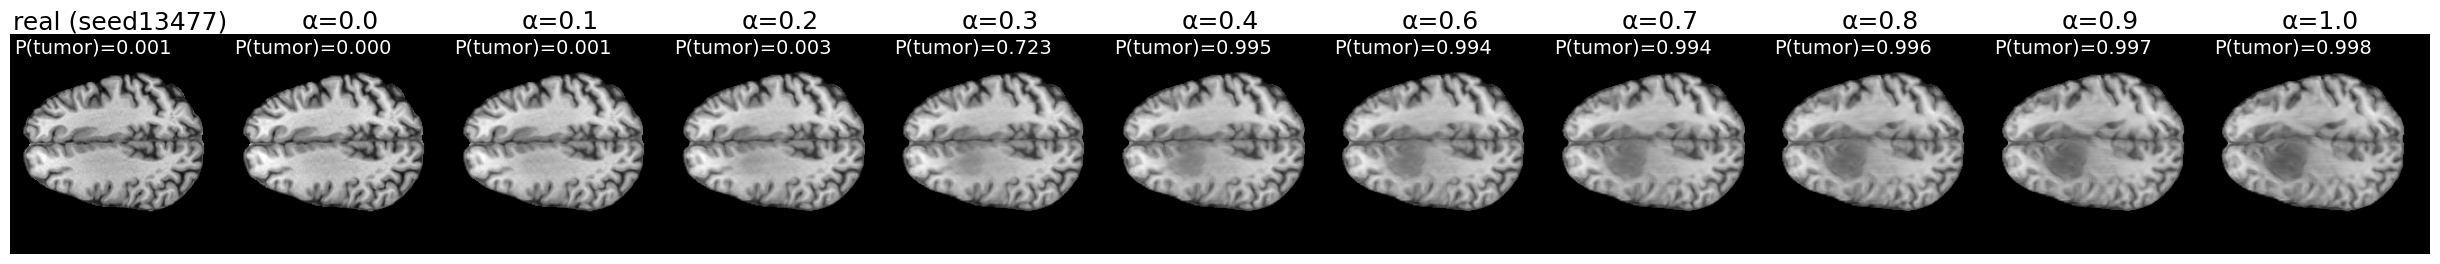

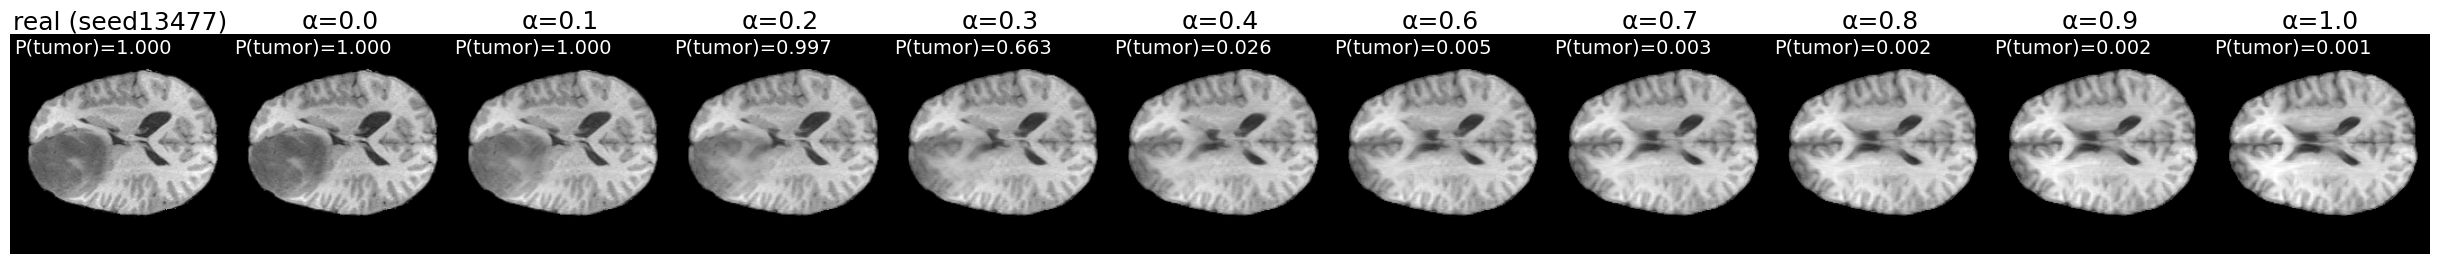

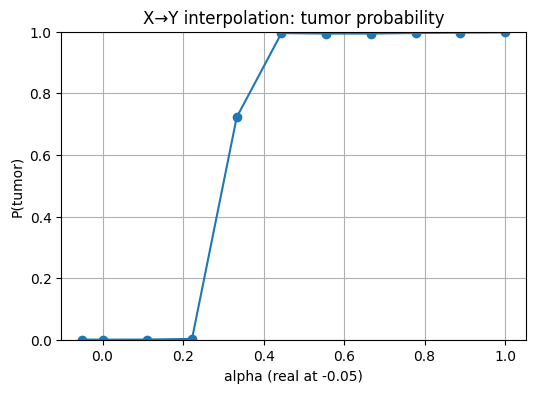

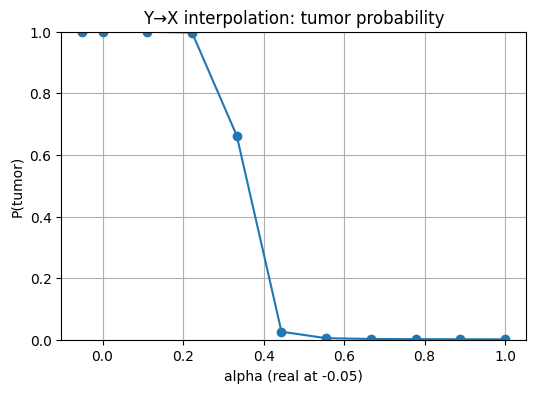

In [27]:
import os
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


# ============================================================
# 0) Add repo to sys.path + import classifier loader
# ============================================================
PROJECT_ROOT = Path("/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med").resolve()

# 确保项目根目录在 sys.path 最前
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

# 清掉缓存（避免之前 import 到错误模块）
for k in list(sys.modules.keys()):
    if k == "models" or k.startswith("models.") or k == "CFgenerating" or k.startswith("CFgenerating."):
        sys.modules.pop(k, None)

from CFgenerating.model_loading import load_classifier
print("✅ load_classifier import OK")


# ============================================================
# 1) Load classifier
# ============================================================
# CKPT_PATH = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/unet_encoder-42/lightning_logs/version_4/checkpoints/loss-epoch=45-val_loss=0.032.ckpt"

# cls_type="unet_encoder"
# cls_ckpt="/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/unet_encoder-42/lightning_logs/version_4/checkpoints/loss-epoch=45-val_loss=0.032.ckpt"

cls_type="resnet"
cls_ckpt="/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/resnet-42/lightning_logs/version_2/checkpoints/loss-epoch=49-val_loss=0.098.ckpt"

# cls_type="densenet"
# cls_ckpt="/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/densenet-42/lightning_logs/version_0/checkpoints/loss-epoch=49-val_loss=0.214.ckpt"



device = "cuda" if torch.cuda.is_available() else "cpu"
classifier = load_classifier(cls_ckpt, cls_type, device)
classifier.eval()
print("✅ classifier loaded on:", device)


# ============================================================
# 2) Seed & Data
# ============================================================
seed = get_random_seeds()  # 或者你手动 seed=13477
seed = 13477

test_bg_dataloader, test_t_dataloader = configure_datasets(
    sfe_model.config,
    test_images=True,
    seed=seed,
    shuffle=True
)

batch_bg = next(iter(test_bg_dataloader))
batch_t  = next(iter(test_t_dataloader))


# ============================================================
# 3) Alpha Range
# ============================================================
alphas_x = torch.linspace(0, 1, steps=10)
alphas_y = torch.linspace(0, 1, steps=10)

titles_x = [f"real (seed{seed})"] + [f"α={a:.1f}" for a in alphas_x]
titles_y = [f"real (seed{seed})"] + [f"α={a:.1f}" for a in alphas_y]


# ============================================================
# 4) Prepare Reconstructions (interpolation)
# ============================================================
recon_X_alpha = []
recon_Y_alpha = []

with torch.no_grad():
    # 如果你需要 method 在 train mode 才能跑你的 pipeline，就保留
    sfe_model.method.train()

    X = batch_bg.to(device).float()
    Y = batch_t.to(device).float()

    X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
    Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)

    c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)

    # real
    recon_X_alpha.append(X_resh)
    recon_Y_alpha.append(Y_resh)

    # deltas
    delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
    delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)

    # interpolation
    for alpha_x, alpha_y in zip(alphas_x, alphas_y):
        swap_f_X2Y = recon_by_delta(X_resh, alpha_x * delta_x2y, sfe_model=sfe_model)
        swap_f_Y2X = recon_by_delta(Y_resh, alpha_y * delta_y2x, sfe_model=sfe_model)
        recon_X_alpha.append(swap_f_X2Y)
        recon_Y_alpha.append(swap_f_Y2X)

print("recon_X_alpha[0] shape:", recon_X_alpha[0].shape)  # 期望 [B,3,256,256]
print("recon_Y_alpha[0] shape:", recon_Y_alpha[0].shape)


# ============================================================
# 5) Classifier prob for each interpolation (3ch -> 1ch)
# ============================================================
def rgb_to_gray_luma(x: torch.Tensor) -> torch.Tensor:
    """
    x: [N,3,H,W] in [-1,1]
    return: [N,1,H,W] (luma weights, similar to PIL convert('L'))
    """
    r, g, b = x[:, 0:1], x[:, 1:2], x[:, 2:3]
    return 0.2989 * r + 0.5870 * g + 0.1140 * b

def ensure_1ch(x: torch.Tensor) -> torch.Tensor:
    """
    x: [N,C,H,W] -> [N,1,H,W]
    """
    if x.shape[1] == 1:
        return x
    if x.shape[1] == 3:
        return rgb_to_gray_luma(x)
    return x.mean(dim=1, keepdim=True)

def probs_for_recon_list(recon_list, classifier, device, t_val=0, idx_in_batch=0):
    """
    recon_list: list of tensors, each [B,3,256,256] in [-1,1]
    idx_in_batch: 取 batch 中第几张做展示/分类（你展示用 0 就一致）
    """
    # 拼成 [N,C,H,W]
    imgs = torch.cat([x[idx_in_batch:idx_in_batch+1] for x in recon_list], dim=0).float().to(device)
    imgs = ensure_1ch(imgs)  # ⭐ 3ch -> 1ch

    t = torch.full((imgs.shape[0],), int(t_val), device=device, dtype=torch.long)

    classifier.eval()
    with torch.no_grad():
        logits = classifier(imgs, t).view(-1)
        probs  = torch.sigmoid(logits)

    return probs.detach().cpu().numpy(), logits.detach().cpu().numpy()

probs_x, logits_x = probs_for_recon_list(recon_X_alpha, classifier, device, t_val=0, idx_in_batch=0)
probs_y, logits_y = probs_for_recon_list(recon_Y_alpha, classifier, device, t_val=0, idx_in_batch=0)

print("X row probs:", probs_x)
print("Y row probs:", probs_y)


# ============================================================
# 6) Crop utils (你原来的显示方式)
# ============================================================
def crop_image(img, w_l=0, w_r=0, h_top=0, h_bot=0):
    w, h = img.size
    return img.crop((w_l, h_top, w - w_r, h - h_bot))

def tensor_to_cropped_img(t, crop_cfg):
    """
    t: tensor [C,H,W] in [-1,1]
    return: numpy image for imshow
    """
    t = ((t.clamp(-1, 1) + 1) / 2).detach().cpu()

    if t.shape[0] == 1:
        img = (t.squeeze(0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img, mode="L")
    else:
        img = (t.permute(1, 2, 0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img)

    pil_img = crop_image(pil_img, **crop_cfg)
    return np.array(pil_img)

h = 5
crop_cfg = dict(
    w_l=30 + h,
    w_r=30 - h,
    h_top=30,
    h_bot=30
)


# ============================================================
# 7) Visualization: title shows alpha, overlay shows prob
# ============================================================
def add_prob_overlay(ax, prob, fontsize=14):
    ax.text(
         0.02, 0.98, f"P(tumor)={prob:.3f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        color="white",
        bbox=dict(facecolor="black", alpha=0.6, pad=2, edgecolor="none"),
    )

num_images   = len(recon_X_alpha)
col_spacing  = 0.0
total_width  = 1.0
img_width    = (total_width - (num_images - 1) * col_spacing) / num_images
title_height = 0.10

# --- FIGURE 1: X row ---
fig_x = plt.figure(figsize=(num_images * 2.2, 3.0))
for i in range(num_images):
    left = i * (img_width + col_spacing)
    ax = fig_x.add_axes([left, 0, img_width, 1 - title_height])

    img = tensor_to_cropped_img(recon_X_alpha[i][0], crop_cfg)
    ax.imshow(img)
    ax.axis("off")

    ax.set_title(titles_x[i], fontsize=18, pad=2)  # 只显示 alpha
    add_prob_overlay(ax, probs_x[i], fontsize=14)  # 左上角 prob

plt.show()

# --- FIGURE 2: Y row ---
fig_y = plt.figure(figsize=(num_images * 2.2, 3.0))
for i in range(num_images):
    left = i * (img_width + col_spacing)
    ax = fig_y.add_axes([left, 0, img_width, 1 - title_height])

    img = tensor_to_cropped_img(recon_Y_alpha[i][0], crop_cfg)
    ax.imshow(img)
    ax.axis("off")

    ax.set_title(titles_y[i], fontsize=18, pad=2)
    add_prob_overlay(ax, probs_y[i], fontsize=14)

plt.show()


# =========================
# 8) alpha-prob curves (X→Y and Y→X)
# =========================
x_axis = np.concatenate(([-0.05], alphas_x.detach().cpu().numpy()))
y_axis = np.concatenate(([-0.05], alphas_y.detach().cpu().numpy()))

plt.figure(figsize=(6,4))
plt.plot(x_axis, probs_x, marker="o")
plt.ylim(0, 1)
plt.xlabel("alpha (real at -0.05)")
plt.ylabel("P(tumor)")
plt.title("X→Y interpolation: tumor probability")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(y_axis, probs_y, marker="o")
plt.ylim(0, 1)
plt.xlabel("alpha (real at -0.05)")
plt.ylabel("P(tumor)")
plt.title("Y→X interpolation: tumor probability")
plt.grid(True)
plt.show()

# 12805

✅ load_classifier import OK
config_set={'model_name': 'densenet', 'model_scale': '121', 'loss_func': 'WeightedBCE', 'weights': [1.0], 'weight_decay': 0.05, 'img_manipulation': 'add_noise', 'sd': <models.diffusion.GuidedDiffusion object at 0x716f6c4733d0>, 'timestep_range': 400, 'diff_train_from_ds': 'brats_2D_256', 'diff_version_num': 0, 'ds_name': 'brats_2D_256', 'img_size': (1, 256, 256), 'labels': ['non-tumor', 'tumor'], 'epochs': 50, 'batch_size': 16, 'lr': 1e-06, 'dropout_rate': 0.5, 'accelerator': 'gpu', 'strategy': 'auto', 'devices': 1, 'num_nodes': 1, 'num_workers': 16, 'device_name': 'cuda'}
121


/home/ids/yuhe/anaconda3/envs/styleGANenv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ids/yuhe/anaconda3/envs/styleGANenv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ classifier loaded on: cuda
Random seed: 12805
Loading dataset
Using dataset: brats_ht_new
recon_X_alpha[0] shape: torch.Size([4, 3, 256, 256])
recon_Y_alpha[0] shape: torch.Size([4, 3, 256, 256])
X row probs: [0.01613687 0.01570458 0.02058229 0.05759924 0.71883124 0.9128895
 0.94561154 0.96306473 0.96345645 0.96654075 0.97014564]
Y row probs: [0.97149336 0.9735068  0.9735752  0.82241464 0.07815644 0.03044299
 0.01999047 0.01508903 0.01230068 0.00991487 0.00926315]


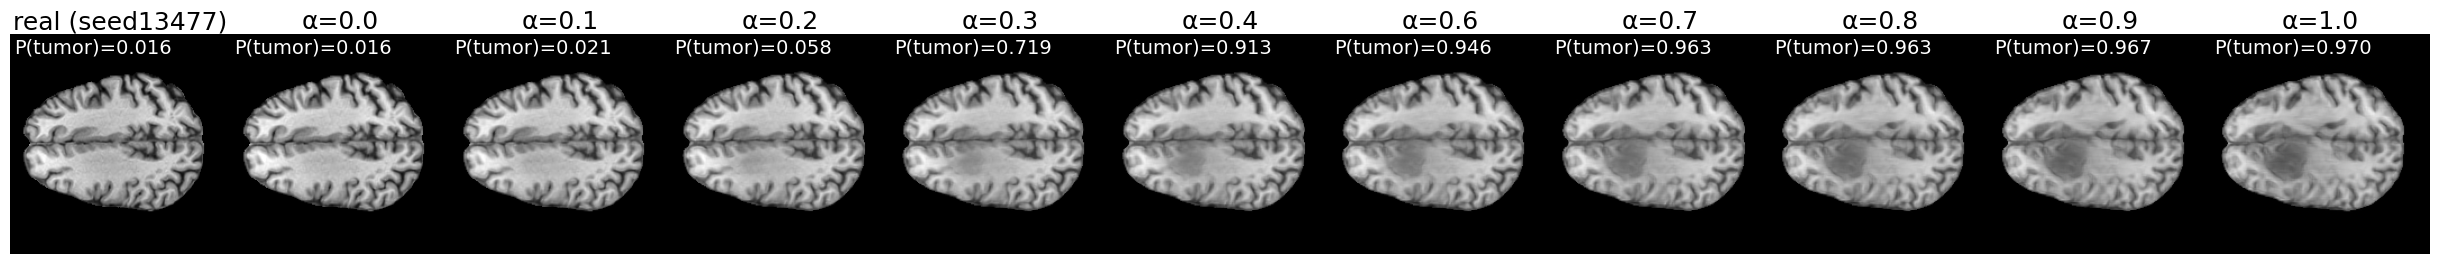

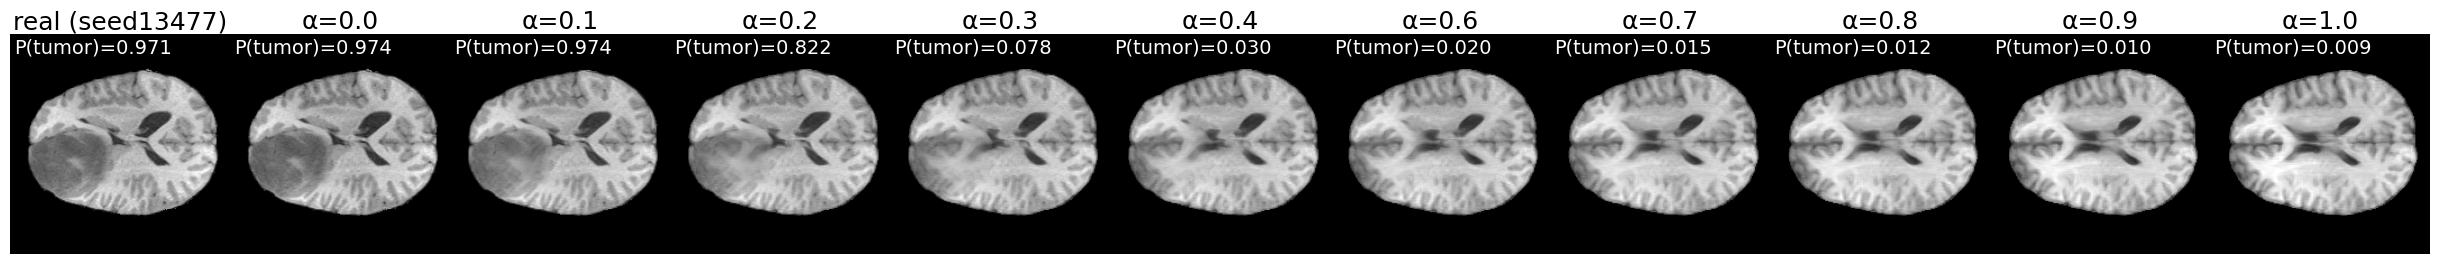

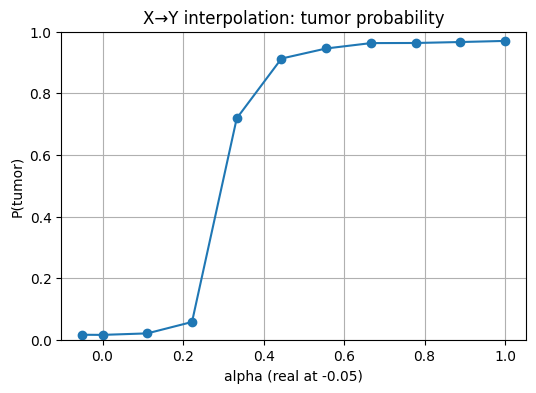

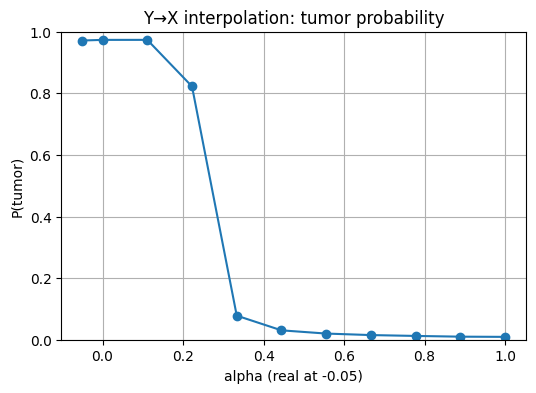

In [29]:
import os
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


# ============================================================
# 0) Add repo to sys.path + import classifier loader
# ============================================================
PROJECT_ROOT = Path("/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med").resolve()

# 确保项目根目录在 sys.path 最前
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

# 清掉缓存（避免之前 import 到错误模块）
for k in list(sys.modules.keys()):
    if k == "models" or k.startswith("models.") or k == "CFgenerating" or k.startswith("CFgenerating."):
        sys.modules.pop(k, None)

from CFgenerating.model_loading import load_classifier
print("✅ load_classifier import OK")


# ============================================================
# 1) Load classifier
# ============================================================
# CKPT_PATH = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/unet_encoder-42/lightning_logs/version_4/checkpoints/loss-epoch=45-val_loss=0.032.ckpt"

# cls_type="unet_encoder"
# cls_ckpt="/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/unet_encoder-42/lightning_logs/version_4/checkpoints/loss-epoch=45-val_loss=0.032.ckpt"

# cls_type="resnet"
# cls_ckpt="/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/resnet-42/lightning_logs/version_2/checkpoints/loss-epoch=49-val_loss=0.098.ckpt"

cls_type="densenet"
cls_ckpt="/home/ids/yuhe/Projects/CA_with_GAN/3_code/FastDiME_Med/records/classifier/brats_2D_256/densenet-42/lightning_logs/version_0/checkpoints/loss-epoch=49-val_loss=0.214.ckpt"



device = "cuda" if torch.cuda.is_available() else "cpu"
classifier = load_classifier(cls_ckpt, cls_type, device)
classifier.eval()
print("✅ classifier loaded on:", device)


# ============================================================
# 2) Seed & Data
# ============================================================
seed = get_random_seeds()  # 或者你手动 seed=13477
seed = 13477

test_bg_dataloader, test_t_dataloader = configure_datasets(
    sfe_model.config,
    test_images=True,
    seed=seed,
    shuffle=True
)

batch_bg = next(iter(test_bg_dataloader))
batch_t  = next(iter(test_t_dataloader))


# ============================================================
# 3) Alpha Range
# ============================================================
alphas_x = torch.linspace(0, 1, steps=10)
alphas_y = torch.linspace(0, 1, steps=10)

titles_x = [f"real (seed{seed})"] + [f"α={a:.1f}" for a in alphas_x]
titles_y = [f"real (seed{seed})"] + [f"α={a:.1f}" for a in alphas_y]


# ============================================================
# 4) Prepare Reconstructions (interpolation)
# ============================================================
recon_X_alpha = []
recon_Y_alpha = []

with torch.no_grad():
    # 如果你需要 method 在 train mode 才能跑你的 pipeline，就保留
    sfe_model.method.train()

    X = batch_bg.to(device).float()
    Y = batch_t.to(device).float()

    X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
    Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)

    c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)

    # real
    recon_X_alpha.append(X_resh)
    recon_Y_alpha.append(Y_resh)

    # deltas
    delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
    delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)

    # interpolation
    for alpha_x, alpha_y in zip(alphas_x, alphas_y):
        swap_f_X2Y = recon_by_delta(X_resh, alpha_x * delta_x2y, sfe_model=sfe_model)
        swap_f_Y2X = recon_by_delta(Y_resh, alpha_y * delta_y2x, sfe_model=sfe_model)
        recon_X_alpha.append(swap_f_X2Y)
        recon_Y_alpha.append(swap_f_Y2X)

print("recon_X_alpha[0] shape:", recon_X_alpha[0].shape)  # 期望 [B,3,256,256]
print("recon_Y_alpha[0] shape:", recon_Y_alpha[0].shape)


# ============================================================
# 5) Classifier prob for each interpolation (3ch -> 1ch)
# ============================================================
def rgb_to_gray_luma(x: torch.Tensor) -> torch.Tensor:
    """
    x: [N,3,H,W] in [-1,1]
    return: [N,1,H,W] (luma weights, similar to PIL convert('L'))
    """
    r, g, b = x[:, 0:1], x[:, 1:2], x[:, 2:3]
    return 0.2989 * r + 0.5870 * g + 0.1140 * b

def ensure_1ch(x: torch.Tensor) -> torch.Tensor:
    """
    x: [N,C,H,W] -> [N,1,H,W]
    """
    if x.shape[1] == 1:
        return x
    if x.shape[1] == 3:
        return rgb_to_gray_luma(x)
    return x.mean(dim=1, keepdim=True)

def probs_for_recon_list(recon_list, classifier, device, t_val=0, idx_in_batch=0):
    """
    recon_list: list of tensors, each [B,3,256,256] in [-1,1]
    idx_in_batch: 取 batch 中第几张做展示/分类（你展示用 0 就一致）
    """
    # 拼成 [N,C,H,W]
    imgs = torch.cat([x[idx_in_batch:idx_in_batch+1] for x in recon_list], dim=0).float().to(device)
    imgs = ensure_1ch(imgs)  # ⭐ 3ch -> 1ch

    t = torch.full((imgs.shape[0],), int(t_val), device=device, dtype=torch.long)

    classifier.eval()
    with torch.no_grad():
        logits = classifier(imgs, t).view(-1)
        probs  = torch.sigmoid(logits)

    return probs.detach().cpu().numpy(), logits.detach().cpu().numpy()

probs_x, logits_x = probs_for_recon_list(recon_X_alpha, classifier, device, t_val=0, idx_in_batch=0)
probs_y, logits_y = probs_for_recon_list(recon_Y_alpha, classifier, device, t_val=0, idx_in_batch=0)

print("X row probs:", probs_x)
print("Y row probs:", probs_y)


# ============================================================
# 6) Crop utils (你原来的显示方式)
# ============================================================
def crop_image(img, w_l=0, w_r=0, h_top=0, h_bot=0):
    w, h = img.size
    return img.crop((w_l, h_top, w - w_r, h - h_bot))

def tensor_to_cropped_img(t, crop_cfg):
    """
    t: tensor [C,H,W] in [-1,1]
    return: numpy image for imshow
    """
    t = ((t.clamp(-1, 1) + 1) / 2).detach().cpu()

    if t.shape[0] == 1:
        img = (t.squeeze(0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img, mode="L")
    else:
        img = (t.permute(1, 2, 0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(img)

    pil_img = crop_image(pil_img, **crop_cfg)
    return np.array(pil_img)

h = 5
crop_cfg = dict(
    w_l=30 + h,
    w_r=30 - h,
    h_top=30,
    h_bot=30
)


# ============================================================
# 7) Visualization: title shows alpha, overlay shows prob
# ============================================================
def add_prob_overlay(ax, prob, fontsize=14):
    ax.text(
         0.02, 0.98, f"P(tumor)={prob:.3f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        color="white",
        bbox=dict(facecolor="black", alpha=0.6, pad=2, edgecolor="none"),
    )

num_images   = len(recon_X_alpha)
col_spacing  = 0.0
total_width  = 1.0
img_width    = (total_width - (num_images - 1) * col_spacing) / num_images
title_height = 0.10

# --- FIGURE 1: X row ---
fig_x = plt.figure(figsize=(num_images * 2.2, 3.0))
for i in range(num_images):
    left = i * (img_width + col_spacing)
    ax = fig_x.add_axes([left, 0, img_width, 1 - title_height])

    img = tensor_to_cropped_img(recon_X_alpha[i][0], crop_cfg)
    ax.imshow(img)
    ax.axis("off")

    ax.set_title(titles_x[i], fontsize=18, pad=2)  # 只显示 alpha
    add_prob_overlay(ax, probs_x[i], fontsize=14)  # 左上角 prob

plt.show()

# --- FIGURE 2: Y row ---
fig_y = plt.figure(figsize=(num_images * 2.2, 3.0))
for i in range(num_images):
    left = i * (img_width + col_spacing)
    ax = fig_y.add_axes([left, 0, img_width, 1 - title_height])

    img = tensor_to_cropped_img(recon_Y_alpha[i][0], crop_cfg)
    ax.imshow(img)
    ax.axis("off")

    ax.set_title(titles_y[i], fontsize=18, pad=2)
    add_prob_overlay(ax, probs_y[i], fontsize=14)

plt.show()


# =========================
# 8) alpha-prob curves (X→Y and Y→X)
# =========================
x_axis = np.concatenate(([-0.05], alphas_x.detach().cpu().numpy()))
y_axis = np.concatenate(([-0.05], alphas_y.detach().cpu().numpy()))

plt.figure(figsize=(6,4))
plt.plot(x_axis, probs_x, marker="o")
plt.ylim(0, 1)
plt.xlabel("alpha (real at -0.05)")
plt.ylabel("P(tumor)")
plt.title("X→Y interpolation: tumor probability")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(y_axis, probs_y, marker="o")
plt.ylim(0, 1)
plt.xlabel("alpha (real at -0.05)")
plt.ylabel("P(tumor)")
plt.title("Y→X interpolation: tumor probability")
plt.grid(True)
plt.show()

# 12805